# Per Disease Classifier

In [ ]:
"""Load Data
Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)

# variables
# run_dir = os.path.join("..","..","outputs","run-25-09-28-05") 
run_dir = os.path.join("..","..","outputs","run-25-09-13-18") 
run_dir = os.path.join("..","..","outputs","run-25-09-13-18") 
run_dir = os.path.join("..","..","outputs","run-25-10-05-01") 
embedding_type = "ft"
assert embedding_type in ["ft", "pt", "raw"]
if embedding_type == "ft":
    output_dir = os.path.join(run_dir, "outputs")
elif embedding_type == "pt":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "outputs")
elif embedding_type == "raw":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "outputs")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions

# 2. Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: rand_stratified
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT_BATCH_LABELS: False
do_combat: False
ontology: do
scgpt_pp: norm_log1p
description: no control loss
library: RNA-Seq
use_controls: True


In [2]:
import importlib
import scanpy as sc

importlib.reload(ut)
importlib.reload(vz)

split_idx = 0

# load all adata
adata_test =  sc.read(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  sc.read(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  sc.read(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  

In [3]:
"""Here we will evaluate the Embeddings
Analyze how well the embeddings capture same disease as well as related diseases
"""

# 1. Imports, Variables, Functions
# imports
from typing import *
from scipy.spatial.distance import cdist    
import itertools
import obonet
import networkx as nx
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
import logging
import os
# variable
is_pre_compute = False

# functions

# 2. Load Data

# load scGPT embeddings
if is_pre_compute:
    pass
else:
    print(f"Using {embedding_type} embeddings")
    if embedding_type == "ft":
        embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
        embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
        embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])
    elif embedding_type == "pt":
        embeddings_test = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "test-pt_embeddings.npy"))
        embeddings_valid = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "valid-pt_embeddings.npy"))
        embeddings_train = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "train-pt_embeddings.npy"))
    elif embedding_type == "raw":
        embeddings_test = adata_test.X
        embeddings_valid = adata_valid.X
        embeddings_train = adata_train.X
    # # import pickle
    # # embeddings_test = pickle.load(open("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/run-25-09-13-18/test-pt_embed_adata.pkl", "rb"))
    # # embeddings_test = embeddings_test.obsm["X_scGPT"]

    # # embeddings_train = pickle.load(open("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/run-25-09-13-18/train-pt_embed_adata.pkl", "rb"))
    # # embeddings_train = embeddings_train.obsm["X_scGPT"]

    # # embeddings_valid = pickle.load(open("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/run-25-09-13-18/valid-pt_embed_adata.pkl", "rb"))
    # # embeddings_valid = embeddings_valid.obsm["X_scGPT"]



    # # compute cosine similarity between all embeddings
    # c_matrix_train = 1 - cdist(embeddings_train, embeddings_train, "cosine")
    # c_matrix_valid = 1 - cdist(embeddings_valid, embeddings_valid, "cosine")
    # c_matrix_test = 1 - cdist(embeddings_test, embeddings_test, "cosine")

    # # compute cosine similarity between sets
    # c_matrix_test_vs_train = 1 - cdist(embeddings_test, embeddings_train, "cosine")
    # c_matrix_valid_vs_train = 1 - cdist(embeddings_valid, embeddings_train, "cosine")

Using ft embeddings


In [4]:
# # build logistic regression model to predict disease from embeddings
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, confusion_matrix
# from sklearn.metrics import ConfusionMatrixDisplay
# from sklearn.metrics import roc_auc_score, average_precision_score
# # one vs rest classifier
# clf = LogisticRegression(multi_class="ovr", max_iter=1000)
# clf.fit(embeddings_train, adata_train.obs["disease"].values)

# y_pred = clf.predict_proba(embeddings_test)
# y_true = adata_test.obs["disease"].values

# print(classification_report(y_true, y_pred))

# y_pred = clf.predict_proba(embeddings_test)



In [5]:
adata_test.obs["disease"].values

['Control', 'Control', 'Control', 'Control', 'Retinoblastoma', ..., 'Control', 'Acquired Immunodeficiency Syndrome', 'Acquired Immunodeficiency Syndrome', 'Acquired Immunodeficiency Syndrome', 'Acquired Immunodeficiency Syndrome']
Length: 5248
Categories (124, object): ['Acne Inversa', 'Acquired Immunodeficiency Syndrome', 'Acute Lymphoblastic Leukemia', 'Acute Myeloid Leukemia', ..., 'Type 1 Diabetes', 'Type 2 Diabetes', 'Ulcerative Colitis', 'Williams Syndrome']

In [6]:
"""0.2 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports


# variables

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)


d_related = dict()
for pair in do_df_ic_query["pair_sorted"].to_list():
    d1, d2 = pair
    if d1 not in d_related:
        d_related[d1] = list()
    if d2 not in d_related:
        d_related[d2] = list()
    d_related[d1].append(d2)
    d_related[d2].append(d1)

Loaded universe of disease pairs: 70442515
IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


In [ ]:
# Logistic Regression with OneVsRestClassifier for probability-based metrics (AUROC, AUPRC, Hit@k)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.multiclass import OneVsRestClassifier

# filter controls out
remove_controls = True

if remove_controls:
    df_train = adata_train.obs[adata_train.obs["disease"] != "Control"]
    df_valid = adata_valid.obs[adata_valid.obs["disease"] != "Control"]
    df_test = adata_test.obs[adata_test.obs["disease"] != "Control"]
    
    e_test = embeddings_test[adata_test.obs["disease"] != "Control"]
    e_valid = embeddings_valid[adata_valid.obs["disease"] != "Control"]
    e_train = embeddings_train[adata_train.obs["disease"] != "Control"]
else:
    df_train = adata_train.obs
    df_valid = adata_valid.obs
    df_test = adata_test.obs

    e_test = embeddings_test
    e_valid = embeddings_valid
    e_train = embeddings_train


# 1) Encode labels using TRAIN classes only
le = LabelEncoder().fit(df_train["doid_id"].values)
y_train = le.transform(df_train["doid_id"].values)

# train
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000))
clf.fit(e_train, y_train)

# 2) testation: restrict to doid_ids seen in TRAIN
test_labels = df_test["doid_id"].values
seen_mask = np.isin(test_labels, le.classes_)                 # only seen doid_ids
Xv = e_test[seen_mask]
yv_str = test_labels[seen_mask]
y_test = le.transform(yv_str)                                  # integer labels (seen only)
print(f"Evaluating on {len(y_test)} test cells from {len(le.classes_)} seen classes")
print(f"Nº of embeddings {Xv.shape} from original {e_test.shape} ")


# 3) Probabilities (no hard predict)
y_proba = clf.predict_proba(Xv)                                 # shape (n_samples, n_train_classes)

# 4) Probability-based metrics
#    (a) Macro AUROC (OvR) and Macro AUPRC over seen classes
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
auroc_macro = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
auprc_macro = average_precision_score(y_test_bin, y_proba, average="macro")

print(f"Macro AUROC (seen classes): {auroc_macro:.3f}")
print(f"Macro AUPRC (seen classes): {auprc_macro:.3f}")

#    (b) Per-class AUROC/AUPRC (optional, useful for doid_id-level reporting)
auroc_per_class = {}
auprc_per_class = {}
for c, name in enumerate(le.classes_):
    y_true_c = (y_test == c).astype(int)
    if y_true_c.sum() == 0:        # this class might not appear in the filtered test set
        continue
    auroc_per_class[name] = roc_auc_score(y_true_c, y_proba[:, c])
    auprc_per_class[name] = average_precision_score(y_true_c, y_proba[:, c])

# 5) Optional: Top-k from probabilities (still no hard predict)
def hit_at_k_from_proba(y_true_int, proba, k=5):
    topk = np.argsort(-proba, axis=1)[:, :k]  # top-k indices (unordered)
    # check if true label is in top-k set per row
    hits = [int(t in row) for t, row in zip(y_true_int, topk)]
    return np.mean(hits)

for k in (1, 5, 10):
    print(f"Hit@{k} (seen classes): {hit_at_k_from_proba(y_test, y_proba, k=k):.3f}")


# Notes:
# - No classification_report or confusion matrix here, since you asked to avoid predict().
# - If you still need a confusion matrix later, use np.argmax(y_proba, axis=1) to get hard labels.


Evaluating on 3611 test cells from 123 seen classes
Nº of embeddings (3611, 512) from original (3611, 512) 
Macro AUROC (seen classes): 0.728
Macro AUPRC (seen classes): 0.134
Hit@1 (seen classes): 0.086
Hit@5 (seen classes): 0.187
Hit@10 (seen classes): 0.322


In [54]:
pairs2ic = dict()
for _, r in do_df_ic_query.iterrows():
    d1, d2, v = r["do1"], r["do2"], r["lin"]
    if d1 not in pairs2ic:
        pairs2ic[d1] = dict()
    if d2 not in pairs2ic:
        pairs2ic[d2] = dict()
        
    pairs2ic[d1][d2] = v
    pairs2ic[d2][d1] = v 


remove_controls = True

if remove_controls:
    df_train = adata_train.obs[adata_train.obs["disease"] != "Control"]
    df_valid = adata_valid.obs[adata_valid.obs["disease"] != "Control"]
    df_test = adata_test.obs[adata_test.obs["disease"] != "Control"]
    
    e_test = embeddings_test[adata_test.obs["disease"] != "Control"]
    e_valid = embeddings_valid[adata_valid.obs["disease"] != "Control"]
    e_train = embeddings_train[adata_train.obs["disease"] != "Control"]
else:
    df_train = adata_train.obs
    df_valid = adata_valid.obs
    df_test = adata_test.obs

    e_test = embeddings_test
    e_valid = embeddings_valid
    e_train = embeddings_train

diseases = df_train["doid_id"].unique()

def get_y_true(df, diseases, pairs2ic):
    def _lookup_ic(d1,d2, pairs2ic):
        if d1 == d2:
            return 2.0
        if d1 not in pairs2ic.keys():
            return 0.0
        return pairs2ic[d1].get(d2, 0.0)

    df.reset_index(drop=True, inplace=True)
    ic_values = np.empty((df.shape[0], len(diseases)))

    for i, d1 in enumerate(diseases):
        print(f"###\t{i}/{df['doid_id'].nunique()}\t###", end="\r")
        for j, d2 in enumerate(df["doid_id"]):
            ic = _lookup_ic(d1, d2, pairs2ic)
            ic_values[j,i] = ic
    return ic_values


test_y_true = get_y_true(df_test, diseases, pairs2ic)
valid_y_true = get_y_true(df_valid, diseases,pairs2ic)
train_y_true = get_y_true(df_train, diseases,pairs2ic)


In [106]:

from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.linear_model import LogisticRegression

class MultiModel:
    def __init__(self, estimator, n_estimators, is_multi_class=True):
        self.estimators = [estimator() for _ in range(n_estimators)]
        self.is_multi_class = is_multi_class
    def fit(self, X, Y):
        """
        Fits one estimator per output column.
        Each column in Y is assumed to be a MultiModel target (e.g., 0, 1, 2).
        """
        for i, est in enumerate(self.estimators):
            print(f"Fitting model {i+1}/{len(self.estimators)}", end="\r")
            
            
            # Handle missing classes gracefully (some may have fewer than 3)
            if not self.is_multi_class:
                # only train with same vs unrelated diseases
                mask_related = ~((Y[:, i] > 0) & (Y[:,i]<1.5))
                print("Nº of non-related diseases:", mask_related.sum())

                
                # binarize labels
                y_bin = np.where(Y[mask_related, i] > 1.5, 1, 0)
                est.fit(X[mask_related], y_bin)
            else:
                y_bin = np.where(Y[:, i] > 1.5, 1, 0)
                est.fit(X, y_bin)


    def predict_proba(self, X):
        """
        Returns two probability matrices:
        - prob_same: probability of class 2
        - prob_related: probability of class 1
        """

        probs = []
        for est in self.estimators:
            proba = est.predict_proba(X)
            # Handle missing classes gracefully (some may have fewer than 3)
            n_classes = proba.shape[1]
            # p_related = proba[:, 1] if n_classes > 1 else np.zeros(X.shape[0])
            # p_same = proba[:, 2] if n_classes > 2 else np.zeros(X.shape[0])

            # prob_related.append(p_related)
            # prob_same.append(p_same)
            probs.append(proba)
        return probs


# Convert continuous relatedness values to 3-class labels
# 0 = unrelated, 1 = related, 2 = same
# train_y_true = np.where(train_y_true < 0.4, 0,
#                  np.where(train_y_true < 1.0, 1, 2)).astype(int)
# test_y_true  = np.where(test_y_true  < 0.4, 0,
#                  np.where(test_y_true  < 1.0, 1, 2)).astype(int)

# Initialize model (multinomial Logistic Regression)
mm = MultiModel(lambda: LogisticRegression(max_iter=1000),
                n_estimators=train_y_true.shape[1], is_multi_class=False)

# Fit
mm.fit(e_train, train_y_true)

# Predict probabilities for “same” and “related”
prob = mm.predict_proba(e_test)
# print("prob_same shape:", prob.shape)
# print("prob_related shape:", prob.shape)


Nº of non-related diseases: 11606
Nº of non-related diseases: 8073
Nº of non-related diseases: 10243
Nº of non-related diseases: 8542
Nº of non-related diseases: 9345
Nº of non-related diseases: 10624
Nº of non-related diseases: 8040
Nº of non-related diseases: 7383
Nº of non-related diseases: 7419
Nº of non-related diseases: 9915
Nº of non-related diseases: 9650
Nº of non-related diseases: 7294
Nº of non-related diseases: 9019
Nº of non-related diseases: 11452
Nº of non-related diseases: 10403
Nº of non-related diseases: 6853
Nº of non-related diseases: 7375
Nº of non-related diseases: 10704
Nº of non-related diseases: 8459
Nº of non-related diseases: 8233
Nº of non-related diseases: 9267
Nº of non-related diseases: 11303
Nº of non-related diseases: 8125
Nº of non-related diseases: 8416
Nº of non-related diseases: 10838
Nº of non-related diseases: 11717
Nº of non-related diseases: 11526
Nº of non-related diseases: 8627
Nº of non-related diseases: 11320
Nº of non-related diseases: 1160

In [107]:
prob = np.array([x[:,1] for x in prob ]).T

In [108]:
auroc_per_dis = dict()
auprc_per_dis = dict()

auroc_per_rel = dict()
auprc_per_rel = dict()
# print metrics
for i, disease_i in enumerate(diseases):
    print(f"Disease: {disease_i}: {doid_to_term.get(disease_i, 'Unknown')}")
    test_y_true_i = np.where(test_y_true[:, i] > 1.5, 1,0).astype(int)
    
    prob_same_i = prob[:,i]
    # prob_related_i = prob_related[:, i]

    # AUROC for "same" (class 2)
    auroc_same = roc_auc_score(test_y_true_i, prob_same_i)
    print(f"  AUROC (same): {auroc_same:.3f}")

    # AUPRC for "same" (class 2)
    auprc_same = average_precision_score(test_y_true_i, prob_same_i)
    print(f"  AUPRC (same): {auprc_same:.3f}")

    test_y_true_i = np.where(test_y_true[:, i] > 0.3, 1,0).astype(int)
    # AUROC for "same" (class 2)
    auroc_rel = roc_auc_score(test_y_true_i, prob_same_i)
    print(f"RELATED  AUROC (same): {auroc_rel:.3f}")

    # AUPRC for "same" (class 2)
    auprc_rel = average_precision_score(test_y_true_i, prob_same_i)
    print(f"RELATED  AUPRC (same): {auprc_rel:.3f}")


    # Store per disease metrics
    auroc_per_dis[disease_i] = auroc_same
    auprc_per_dis[disease_i] = auprc_same

    auroc_per_rel[disease_i] = auroc_rel
    auprc_per_rel[disease_i] = auprc_rel



Disease: DOID:11714: gestational diabetes
  AUROC (same): 0.975
  AUPRC (same): 0.196
RELATED  AUROC (same): 0.750
RELATED  AUPRC (same): 0.112
Disease: DOID:10286: prostate carcinoma
  AUROC (same): 1.000
  AUPRC (same): 1.000
RELATED  AUROC (same): 0.891
RELATED  AUPRC (same): 0.888
Disease: DOID:332: amyotrophic lateral sclerosis
  AUROC (same): 0.570
  AUPRC (same): 0.002
RELATED  AUROC (same): 0.656
RELATED  AUPRC (same): 0.175
Disease: DOID:2526: prostate adenocarcinoma
  AUROC (same): 0.556
  AUPRC (same): 0.006
RELATED  AUROC (same): 0.879
RELATED  AUPRC (same): 0.890
Disease: DOID:8577: ulcerative colitis
  AUROC (same): 0.959
  AUPRC (same): 0.180
RELATED  AUROC (same): 0.789
RELATED  AUPRC (same): 0.478
Disease: DOID:2841: asthma
  AUROC (same): 0.708
  AUPRC (same): 0.008
RELATED  AUROC (same): 0.597
RELATED  AUPRC (same): 0.335
Disease: DOID:4947: cholangiocarcinoma
  AUROC (same): 0.802
  AUPRC (same): 0.031
RELATED  AUROC (same): 0.933
RELATED  AUPRC (same): 0.965
Diseas

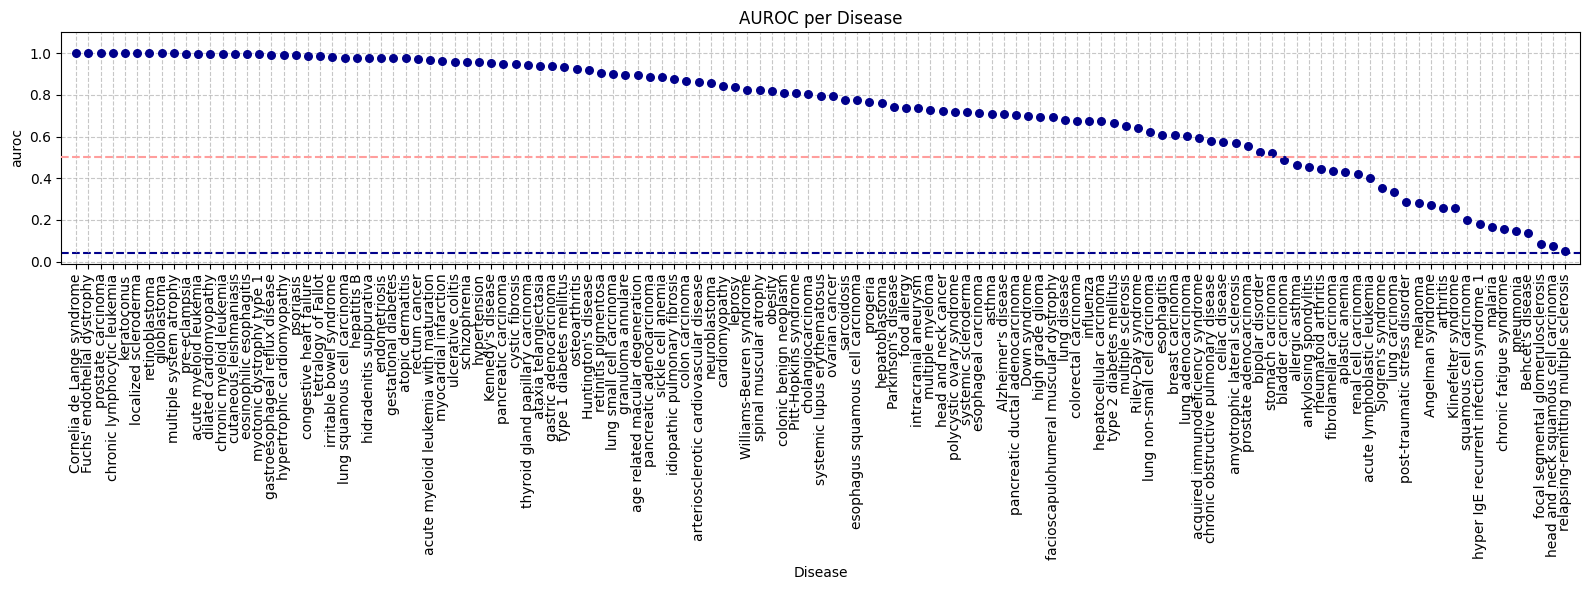

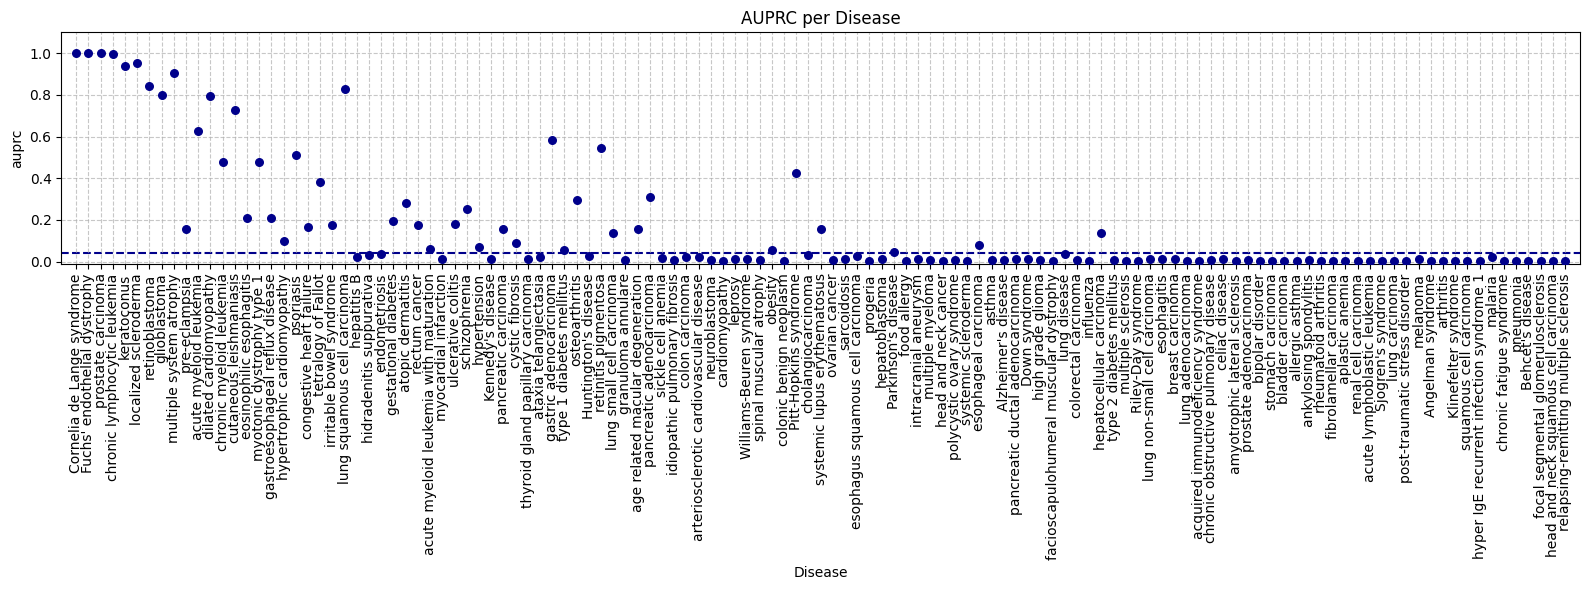

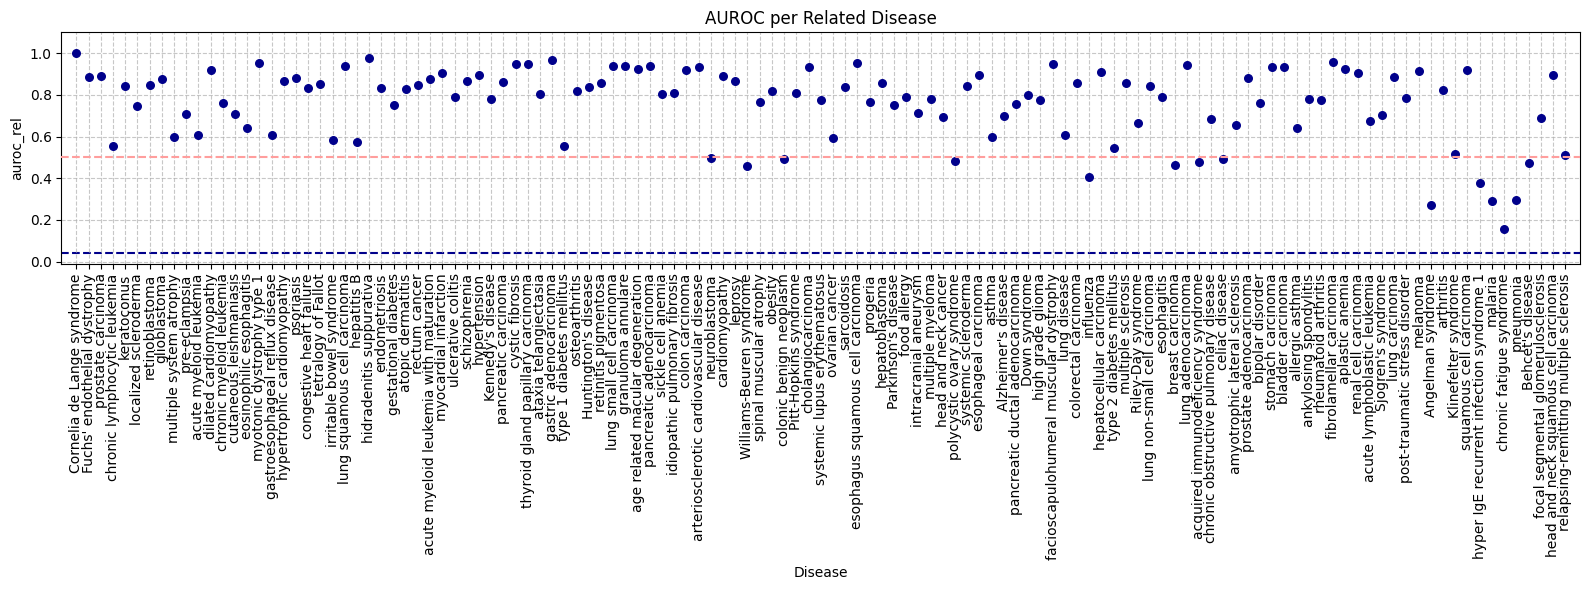

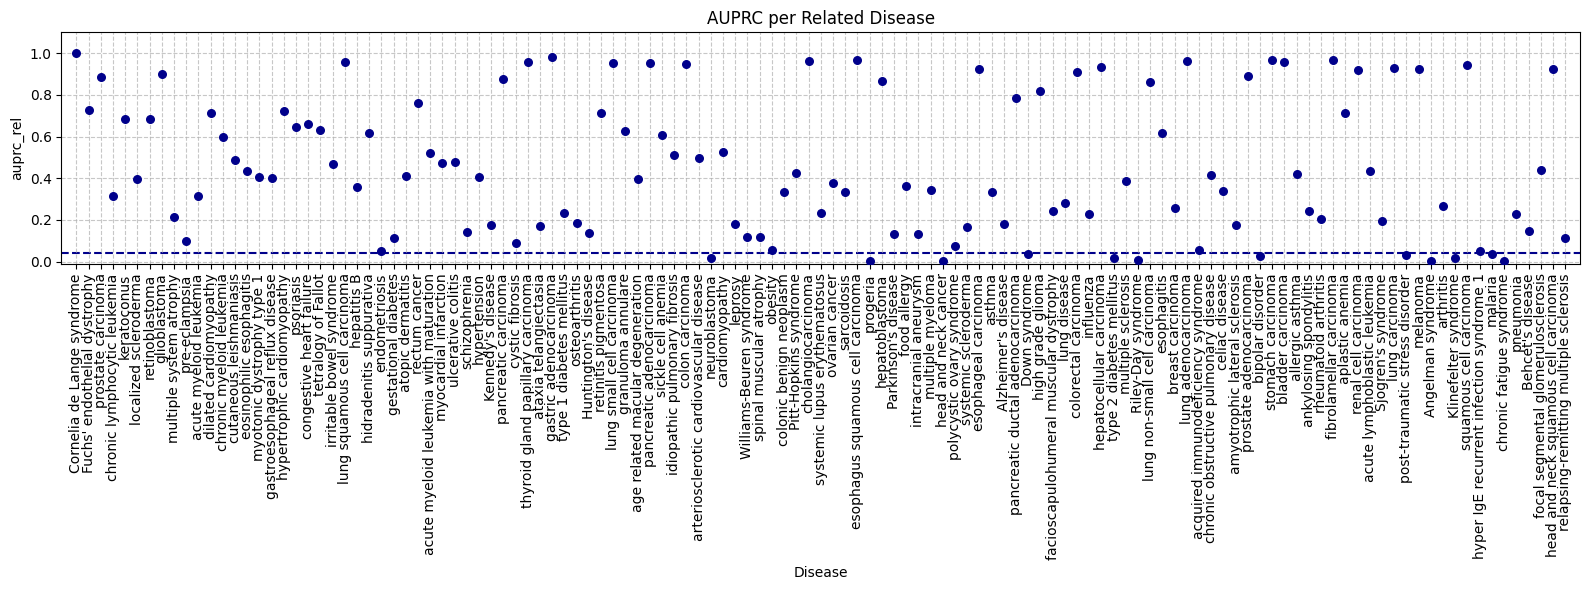

In [109]:
def plot_lollipop(x_vals, labels, title, metric, color, stds=None, capsize=3, linewidth=1.5, k=5):
    import numpy as np
    import matplotlib.pyplot as plt

    x_vals = np.asarray(x_vals, dtype=float)
    labels = list(labels)
    xpos = np.arange(len(labels))

    # compute y-limit to include error bars if provided
    ymax = np.nanmax(x_vals + (np.asarray(stds) if stds is not None else 0))
    ymax = float(ymax) if np.isfinite(ymax) else 1.0

    plt.figure(figsize=(16, 6))

    # error bars first (so dots are on top)
    if stds is not None:
        stds = np.asarray(stds, dtype=float)
        plt.errorbar(
            xpos, x_vals, yerr=stds,
            fmt='none', ecolor=color, elinewidth=linewidth, capsize=capsize,
            alpha=0.9, zorder=2
        )

    # dots
    plt.scatter(xpos, x_vals, color=color, s=30, zorder=3)

    # baseline crosses at 0 (optional; scalar broadcasts)
    rand_baseline = 1/len(labels)*k
    # plt.scatter(xpos, [rand_baseline]*len(labels), color=color, s=30, zorder=3, marker="x")
    plt.axhline(y=rand_baseline, color=color, linestyle='--', linewidth=1.5,alpha=1, zorder=1)

    # cosmetics
    plt.xticks(xpos, labels, rotation=90)
    plt.margins(x=0.01, y=0.1)
    plt.ylim(-0.01, ymax + 0.1)
    plt.grid(linestyle='--', alpha=0.7, zorder=0)
    # plt.axhline(y=1, color="#ff9e9d", linestyle='--', linewidth=1, zorder=1)
    if metric.lower().startswith("auroc"):
        plt.axhline(y=0.5, color="#ff9e9d", linestyle='--', linewidth=1.5, alpha=1, zorder=3)
    
    plt.xlabel("Disease")
    plt.ylabel(f"{metric}")
    plt.title(f"{title}")

    # only show legend if you actually add handles; here we skip it
    plt.tight_layout()
    plt.show()

_dis = list(auroc_per_dis.keys())
_df_plot = pd.DataFrame({
    "doid": _dis,
    "disease": [doid_to_term.get(d, "Unknown") for d in _dis],
    "auroc": [auroc_per_dis[d] for d in _dis],
    "auprc": [auprc_per_dis[d] for d in _dis],
    "auroc_rel": [auroc_per_rel[d] for d in _dis],
    "auprc_rel": [auprc_per_rel[d] for d in _dis],
})

_df_plot.sort_values(["auroc", "auprc"], ascending=[False,False], inplace=True)

# Same disease
plot_lollipop(_df_plot["auroc"].to_list(), _df_plot["disease"].to_list(), f"AUROC per Disease", "auroc", "darkblue", stds=None)
plot_lollipop(_df_plot["auprc"].to_list(), _df_plot["disease"].to_list(), f"AUPRC per Disease", "auprc", "darkblue", stds=None)

# Related disease
plot_lollipop(_df_plot["auroc_rel"].to_list(), _df_plot["disease"].to_list(), f"AUROC per Related Disease", "auroc_rel", "darkblue", stds=None)
plot_lollipop(_df_plot["auprc_rel"].to_list(), _df_plot["disease"].to_list(), f"AUPRC per Related Disease", "auprc_rel", "darkblue", stds=None)

In [102]:
def hit_at_k_from_proba(y_true_int, proba,d_related, k=5):
    
    # get all related doids in 2D array
    y_doids = np.array(le.inverse_transform(y_true_int))
    y_related = []
    for d in y_doids:
        y_related.append(d_related.get(d, []))

    # get topk doids
    topk = np.argsort(-proba, axis=1)[:, :k]  # top-k indices (unordered)
    topk_doids = np.array(le.classes_)[np.argsort(-y_proba, axis=1)[:, :k]]

    # get hits
    hits_same = [len(set([_doid]) & set(_top_ks)) for _doid, _top_ks in zip(y_doids, topk_doids)]
    hits_related = [len(set(_doids) & set(_top_ks)) for _doids, _top_ks in zip(y_related, topk_doids)]
    hits_unrelated = [k - s - r for s, r in zip(hits_same, hits_related)]

    df_results = pd.DataFrame({
        "doid": y_doids,
        "topk": list(topk_doids),
        "hit@k": hits_same,
        "n_related": hits_related,
        "n_unrelated": hits_unrelated,
    })

    return df_results



def hit_at_k_from_proba(y_true_doids, proba,diseases,d_related, k=5):
    
    # get all related doids in 2D array
    y_true_doids = np.array(y_true_doids)

    doids = np.array(diseases)

    y_related = []
    for d in y_true_doids:
        y_related.append(d_related.get(d, []))

    # get topk doids
    topk_idxs = np.argsort(-proba, axis=1)[:, :k] # top-k indices (unordered)
    print(topk_idxs)
    topk_doids = doids[topk_idxs]  

    # get hits
    hits_same = [len(set([_doid]) & set(list(_top_ks))) for _doid, _top_ks in zip(y_true_doids, topk_doids)]
    hits_related = [len(set(_doids) & set(_top_ks)) for _doids, _top_ks in zip(y_related, topk_doids)]
    hits_unrelated = [k - s - r for s, r in zip(hits_same, hits_related)]



    df_results = pd.DataFrame({
        "doid": y_true_doids,
        "topk": list(topk_doids),
        "hit@k": hits_same,
        "n_related": hits_related,
        "n_unrelated": hits_unrelated,
    })

    return df_results


hit_at_k_from_proba(df_test["doid_id"], prob, diseases, d_related, k=5)

[[120  11 122  74  54]
 [120  46 122  98  11]
 [120  46  98 122  11]
 ...
 [ 23   4  24  32 121]
 [ 23   4  32  52 116]
 [ 23   4  32  52 116]]


,doid,topk,hit@k,n_related,n_unrelated
0,DOID:768,"[DOID:768, DOID:0080199, DOID:10584, DOID:3905...",1,1,3
1,DOID:768,"[DOID:768, DOID:3908, DOID:10584, DOID:12449, ...",1,1,3
2,DOID:768,"[DOID:768, DOID:3908, DOID:12449, DOID:10584, ...",1,1,3
3,DOID:768,"[DOID:768, DOID:12449, DOID:10584, DOID:008019...",1,1,3
4,DOID:768,"[DOID:768, DOID:0080199, DOID:3908, DOID:12449...",1,1,3
...,...,...,...,...,...
3606,DOID:3910,"[DOID:11612, DOID:9352, DOID:3068, DOID:12449,...",0,1,4
3607,DOID:635,"[DOID:2377, DOID:8577, DOID:3310, DOID:3459, D...",0,0,5
3608,DOID:635,"[DOID:2377, DOID:8577, DOID:3310, DOID:3459, D...",0,0,5
3609,DOID:635,"[DOID:2377, DOID:8577, DOID:3459, DOID:12858, ...",0,0,5


In [98]:
prob

array([[2.27101746e-08, 3.33803265e-08, 2.54402675e-08, ...,
        6.15356579e-01, 3.35128293e-06, 2.87660119e-02],
       [6.94931638e-08, 7.94901442e-08, 2.41708300e-08, ...,
        9.35995720e-01, 1.70203176e-05, 1.44617190e-02],
       [7.68388733e-08, 2.87623743e-07, 3.45573125e-08, ...,
        9.06943298e-01, 2.74026357e-05, 1.23913855e-02],
       ...,
       [7.54881554e-11, 2.51962201e-05, 3.78254860e-13, ...,
        1.99662986e-05, 6.17437496e-04, 3.51725550e-05],
       [4.65382538e-12, 6.56117295e-07, 1.44024471e-10, ...,
        9.67388009e-06, 7.48633050e-05, 2.34767428e-05],
       [3.40996725e-12, 2.93631122e-06, 9.88077731e-11, ...,
        9.07707521e-06, 1.52107816e-04, 2.16613782e-05]])

In [96]:
np.argsort(-prob, axis=1)

array([[120,  11, 122, ...,  45,  16,   7],
       [120,  46, 122, ...,  19,   7,  94],
       [120,  46,  98, ...,  44,  34,  94],
       ...,
       [ 23,   4,  24, ...,  94,  18,   2],
       [ 23,   4,  32, ...,  46,   0,  33],
       [ 23,   4,  32, ...,  33,  18,   0]])

In [94]:
np.argsort(-prob[0])

array([120,  11, 122,  74,  54,  41,  88, 110,  51,  18, 112,  73,  84,
        98,  47, 115,  13,  92, 101,  24,  77,  93,  60,  82,  90,  95,
        66, 118, 111, 102,  69,  71, 109,  61, 116,   8,  58,  57,  64,
        96, 119,  76,  42,  75, 117,  55, 103,  15,   9,  38,  31,  46,
        80, 121,  26, 114,  89,  30, 108, 105,  29,  27,  22,  72,  48,
        53,  87,  63,  32,  67,  50,  35,  49,  36,  33,  83,  14, 107,
        81,  56,  86,  70, 106, 113,  21,   4,  25,  62,  43,  65,  85,
        39,   6,  99,  10,  78,   1,  40,   2, 104,   0,  17,  97,  79,
       100,   5,  37,  23,  52,  68,  20,  12,   3,  34,  59,  91,  28,
        44,  94,  19,  45,  16,   7])

In [88]:
df_test["doid_id"]

0        DOID:768
1        DOID:768
2        DOID:768
3        DOID:768
4        DOID:768
          ...    
3606    DOID:3910
3607     DOID:635
3608     DOID:635
3609     DOID:635
3610     DOID:635
Name: doid_id, Length: 3611, dtype: category
Categories (124, object): ['Control', 'DOID:235', 'DOID:289', 'DOID:332', ..., 'DOID:0060161', 'DOID:0060488', 'DOID:0080199', 'DOID:0081087']

In [87]:
diseases[np.argsort(prob[0,:])[::-1]][:5]

['DOID:768', 'DOID:0080199', 'DOID:10584', 'DOID:3905', 'DOID:5015']
Categories (124, object): ['Control', 'DOID:235', 'DOID:289', 'DOID:332', ..., 'DOID:0060161', 'DOID:0060488', 'DOID:0080199', 'DOID:0081087']

[[120 122  11]
 [120 122  88]
 [120 122  11]
 ...
 [ 23   4  60]
 [ 23  60   4]
 [ 23  60   4]]


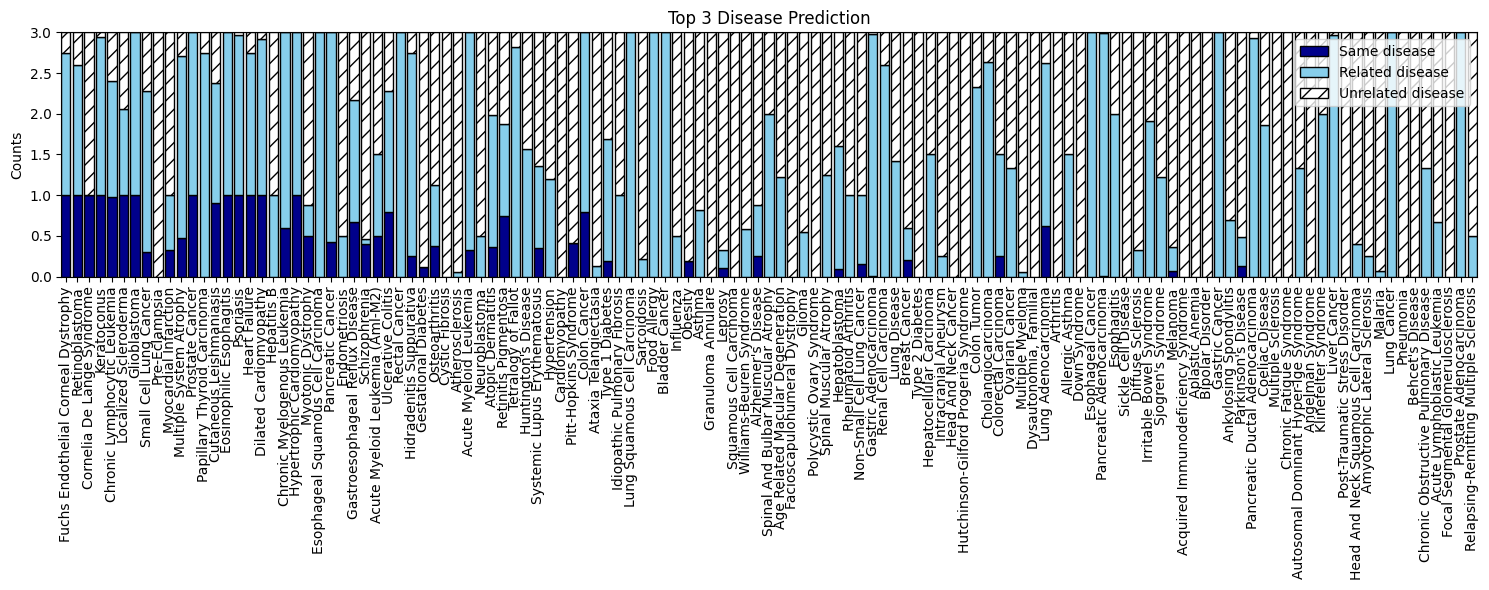

In [120]:
k = 3
# df_hits = hit_at_k_from_proba(y_test, y_proba, d_related, k=k)
df_hits = hit_at_k_from_proba(df_test["doid_id"], prob, diseases, d_related, k=k)

doid_2_dis = dict(zip(adata_train.obs["doid_id"], adata_train.obs["disease"]))
df_hits["disease"] = df_hits["doid"].map(doid_2_dis)

_df_grouped = (
    df_hits
    .groupby("disease")
    .agg({
        "hit@k": "mean",
        "n_related": "mean",
        "n_unrelated": "mean",
        "doid": "first"     # <- keep the doid_id
    })
    .rename(columns={"doid": "doid_id"})
    .sort_values("n_unrelated")
    .reset_index()
)


# dis_order = _df_grouped["disease"].to_list()


# add auprc and auroc
_df_grouped["auprc"] = _df_grouped["doid_id"].map(auprc_per_class)
_df_grouped["auroc"] = _df_grouped["doid_id"].map(auroc_per_class)

_df_grouped["auroc_round"] = _df_grouped["auroc"].round(1)
_df_grouped["auprc_round"] = _df_grouped["auprc"].round(1)

# sort values
_df_grouped.sort_values(["auroc", "auprc"], ascending=[False, False], inplace=True)

_same_counts = _df_grouped["hit@k"].to_list()
_related_counts = _df_grouped["n_related"].to_list()
_unrelated_counts = _df_grouped["n_unrelated"].to_list()

dis_order = _df_grouped["disease"].to_list()

x = np.arange(len(_df_grouped))

fig, ax = plt.subplots(figsize=(15, 6))

# Stacked vertical bars
bars_same = ax.bar(x, _same_counts, color="darkblue", label="Same disease", edgecolor="black")
bars_related = ax.bar(x, _related_counts, bottom=_same_counts,
                      color="skyblue", label="Related disease", edgecolor="black")
bars_unrelated = ax.bar(
    x, _unrelated_counts,
    bottom=np.array(_same_counts) + np.array(_related_counts),
    color="white", edgecolor="black", hatch="//",  label="Unrelated disease"
)

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(dis_order, rotation=90)
ax.set_ylabel("Counts")
ax.set_title(f"Top {k} Disease Prediction")
ax.legend()

    
plt.margins(x=0.0, y=0.0)
plt.ylim(-0.0, k)  # adjust if your totals differ
plt.tight_layout()
plt.show()


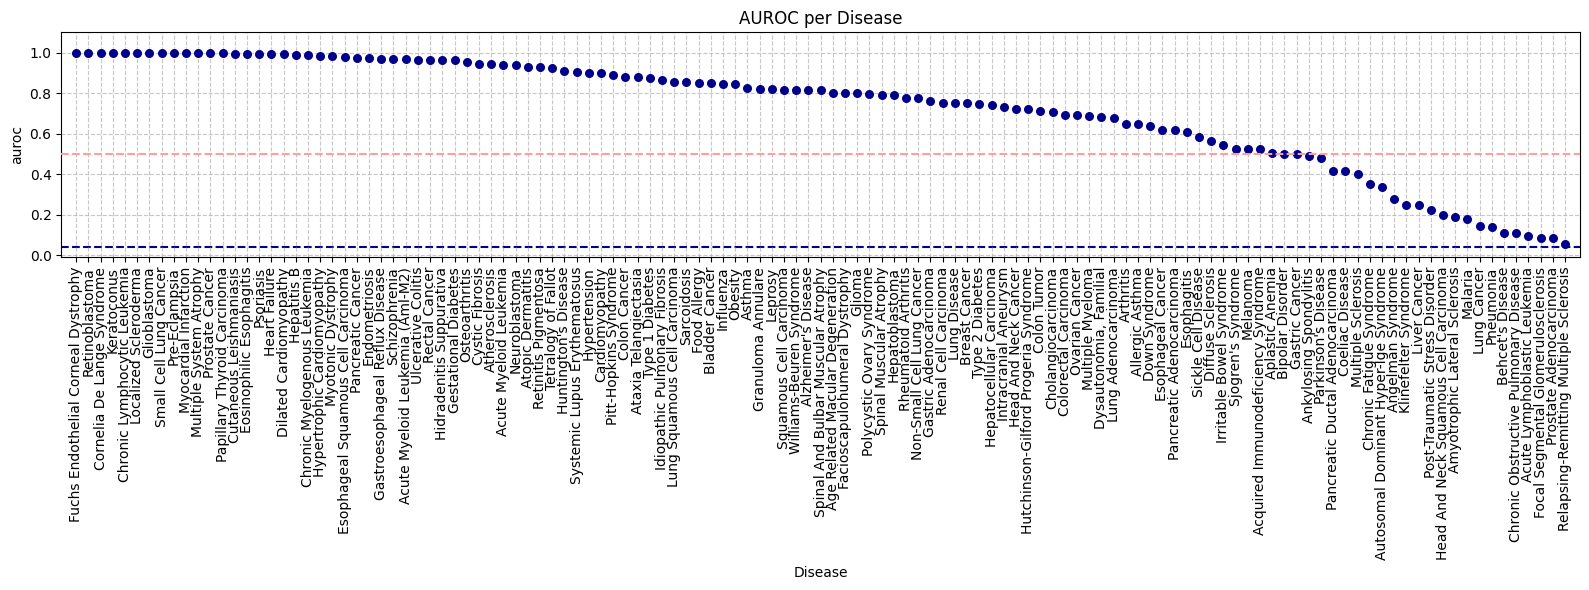

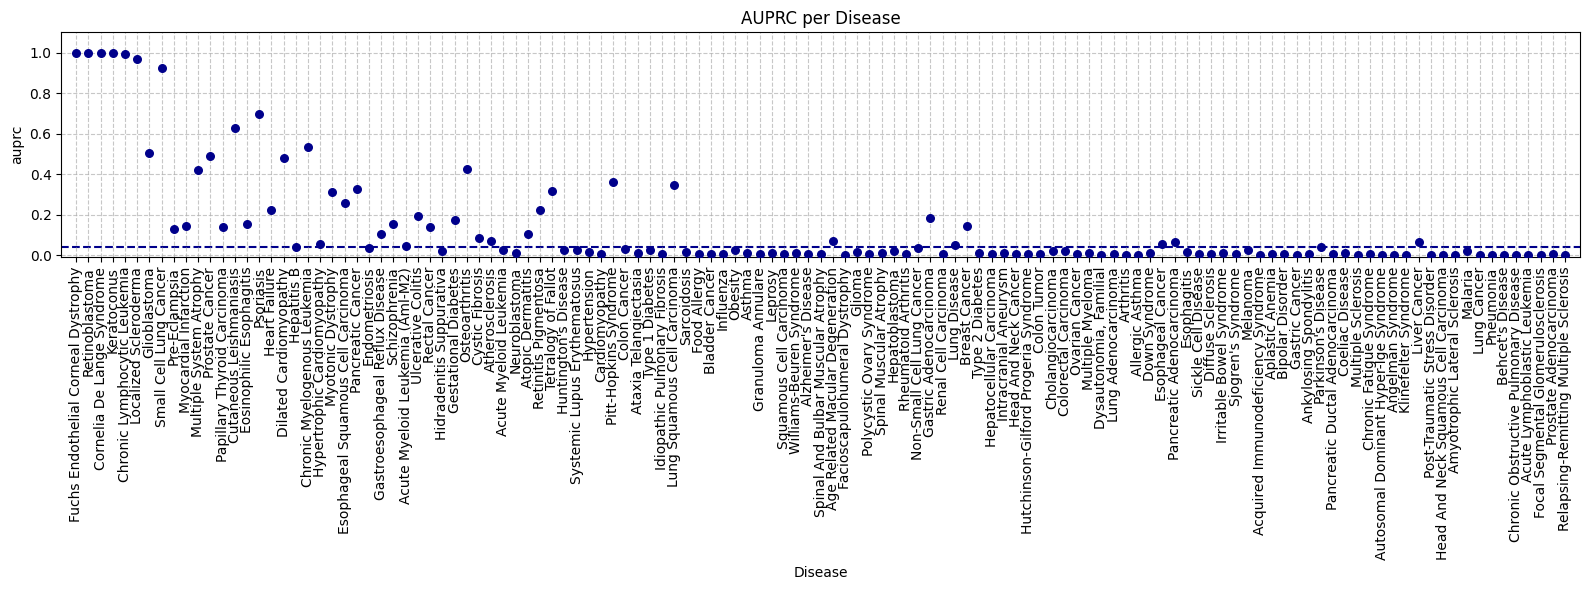

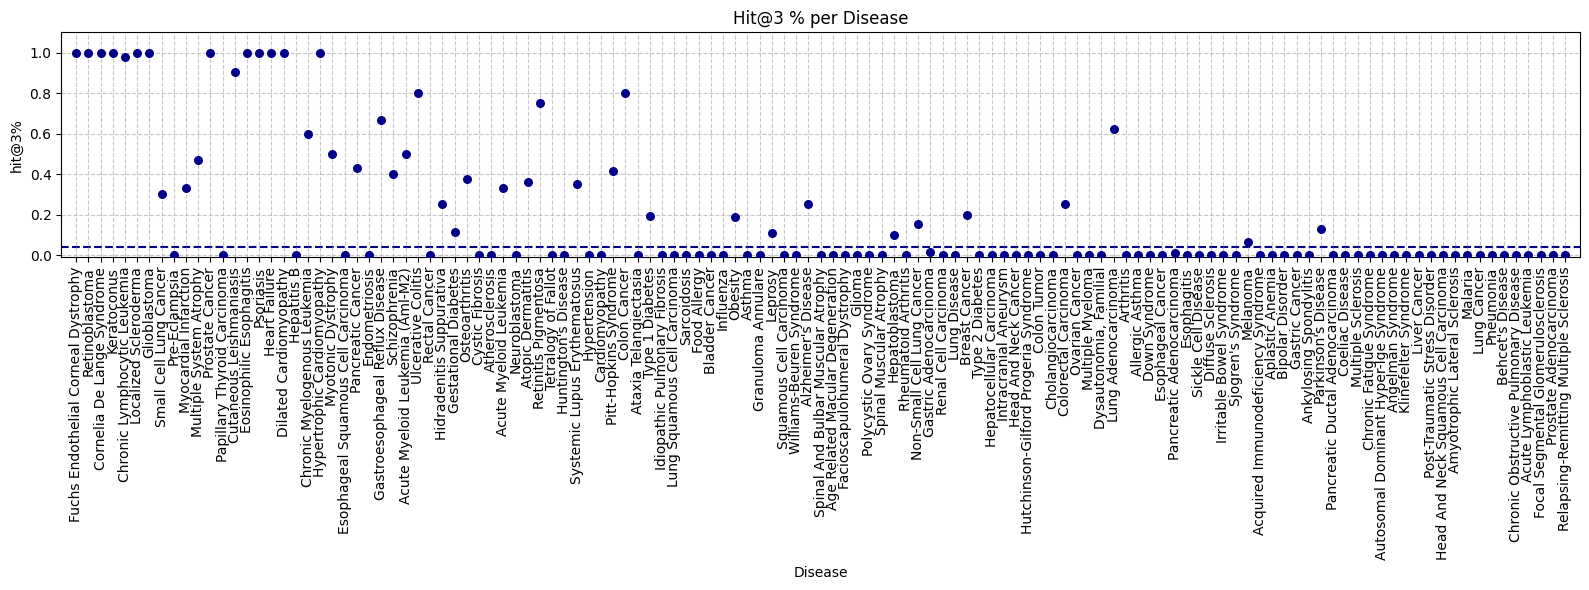

In [121]:
def plot_lollipop(x_vals, labels, title, metric, color, stds=None, capsize=3, linewidth=1.5, k=5):
    import numpy as np
    import matplotlib.pyplot as plt

    x_vals = np.asarray(x_vals, dtype=float)
    labels = list(labels)
    xpos = np.arange(len(labels))

    # compute y-limit to include error bars if provided
    ymax = np.nanmax(x_vals + (np.asarray(stds) if stds is not None else 0))
    ymax = float(ymax) if np.isfinite(ymax) else 1.0

    plt.figure(figsize=(16, 6))

    # error bars first (so dots are on top)
    if stds is not None:
        stds = np.asarray(stds, dtype=float)
        plt.errorbar(
            xpos, x_vals, yerr=stds,
            fmt='none', ecolor=color, elinewidth=linewidth, capsize=capsize,
            alpha=0.9, zorder=2
        )

    # dots
    plt.scatter(xpos, x_vals, color=color, s=30, zorder=3)

    # baseline crosses at 0 (optional; scalar broadcasts)
    rand_baseline = 1/len(labels)*k
    # plt.scatter(xpos, [rand_baseline]*len(labels), color=color, s=30, zorder=3, marker="x")
    plt.axhline(y=rand_baseline, color=color, linestyle='--', linewidth=1.5,alpha=1, zorder=1)

    # cosmetics
    plt.xticks(xpos, labels, rotation=90)
    plt.margins(x=0.01, y=0.1)
    plt.ylim(-0.01, ymax + 0.1)
    plt.grid(linestyle='--', alpha=0.7, zorder=0)
    # plt.axhline(y=1, color="#ff9e9d", linestyle='--', linewidth=1, zorder=1)
    if metric.lower() == "auroc":
        plt.axhline(y=0.5, color="#ff9e9d", linestyle='--', linewidth=1.5, alpha=1, zorder=3)
    
    plt.xlabel("Disease")
    plt.ylabel(f"{metric}")
    plt.title(f"{title}")

    # only show legend if you actually add handles; here we skip it
    plt.tight_layout()
    plt.show()


plot_lollipop(_df_grouped["auroc"].to_list(), _df_grouped["disease"].to_list(), f"AUROC per Disease", "auroc", "darkblue", stds=None)
plot_lollipop(_df_grouped["auprc"].to_list(), _df_grouped["disease"].to_list(), f"AUPRC per Disease", "auprc", "darkblue", stds=None)
plot_lollipop(_df_grouped["hit@k"].to_list(), _df_grouped["disease"].to_list(), f"Hit@{k} % per Disease", f"hit@{k}%", "darkblue", stds=None)


In [ ]:
def get_predict(disease):
    """Return true labels and predicted probabilities for a given disease."""
    
    # Loop over label encoder classes
    for c, name in enumerate(le.classes_):
        if name == disease:
            y_true_c = (y_test == c).astype(int)
            
            # Handle case where the disease is missing in y_test
            if y_true_c.sum() == 0:
                print(f"No samples of '{disease}' found in the test set.")
                return None
            
            y_pred_c = y_proba[:, c]
            return y_true_c, y_pred_c

    # If disease name not in label encoder
    print(f"'{disease}' not found in label encoder classes.")
    return None

disease_2_doid = dict(zip(adata_train.obs["disease"], adata_train.obs["doid_id"]))
_y_true, _y_pred = get_predict(disease_2_doid.get("Lung Squamous Cell Carcinoma"))

Text(0.5, 1.0, 'Predicted Probabilities for Lung Squamous Cell Carcinoma')

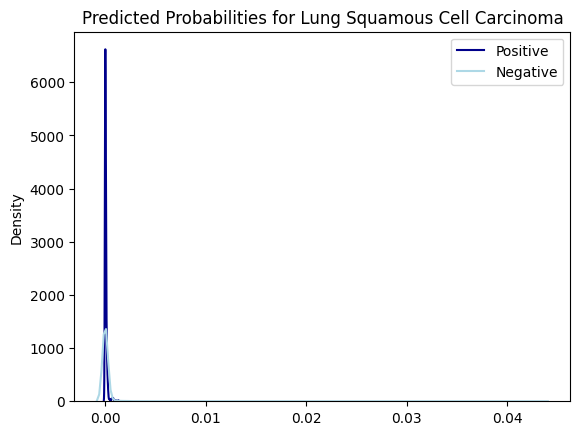

In [ ]:
sns.kdeplot(_y_pred[_y_true==1], color="darkblue", label="Positive",)
sns.kdeplot(_y_pred[_y_true==0], color="lightblue", label="Negative",)
plt.legend()
plt.title("Predicted Probabilities for Lung Squamous Cell Carcinoma")

In [ ]:
le.classes_

array(['DOID:0050156', 'DOID:0050700', 'DOID:0060161', 'DOID:0060488',
       'DOID:0080199', 'DOID:0081087', 'DOID:10126', 'DOID:1024',
       'DOID:10286', 'DOID:1040', 'DOID:10584', 'DOID:10591',
       'DOID:10608', 'DOID:10652', 'DOID:10763', 'DOID:10871',
       'DOID:10923', 'DOID:10941', 'DOID:1107', 'DOID:11335',
       'DOID:11555', 'DOID:11589', 'DOID:11612', 'DOID:11714',
       'DOID:11722', 'DOID:11725', 'DOID:11727', 'DOID:11934',
       'DOID:11963', 'DOID:11984', 'DOID:12365', 'DOID:12377',
       'DOID:12449', 'DOID:12704', 'DOID:12858', 'DOID:12894',
       'DOID:12930', 'DOID:1312', 'DOID:13241', 'DOID:13922',
       'DOID:14250', 'DOID:14330', 'DOID:1485', 'DOID:1520', 'DOID:1749',
       'DOID:1909', 'DOID:1921', 'DOID:1928', 'DOID:1932', 'DOID:1993',
       'DOID:2043', 'DOID:2055', 'DOID:2280', 'DOID:2348', 'DOID:235',
       'DOID:2377', 'DOID:2378', 'DOID:2394', 'DOID:2526', 'DOID:2841',
       'DOID:289', 'DOID:3044', 'DOID:3068', 'DOID:3070', 'DOID:3083',
  

In [ ]:
_df_grouped

,hit@k,n_related,n_unrelated
disease,,,
Colon Cancer,0.850000,4.100000,0.050000
Gastric Adenocarcinoma,0.013333,4.757333,0.229333
Esophageal Squamous Cell Carcinoma,0.083333,4.562500,0.354167
Prostate Adenocarcinoma,0.000000,4.611111,0.388889
Prostate Cancer,1.000000,3.500000,0.500000
...,...,...,...
Polycystic Ovary Syndrome,0.000000,0.000000,5.000000
Pneumonia,0.000000,0.000000,5.000000
Cardiomyopathy,0.000000,0.000000,5.000000


In [ ]:
df_hits["auprc"] = df_hits["doid"].map(auprc_per_class)
df_hits["auroc"] = df_hits["doid"].map(auroc_per_class)

In [ ]:
df_hits

,doid,topk,hit@k,n_related,n_unrelated,disease,auprc,auroc
0,DOID:768,"[DOID:768, DOID:0080199, DOID:10584, DOID:3905...",1,1,3,Retinoblastoma,1.000000,1.000000
1,DOID:768,"[DOID:768, DOID:3908, DOID:10584, DOID:12449, ...",1,1,3,Retinoblastoma,1.000000,1.000000
2,DOID:768,"[DOID:768, DOID:3908, DOID:12449, DOID:10584, ...",1,1,3,Retinoblastoma,1.000000,1.000000
3,DOID:768,"[DOID:768, DOID:12449, DOID:10584, DOID:008019...",1,1,3,Retinoblastoma,1.000000,1.000000
4,DOID:768,"[DOID:768, DOID:0080199, DOID:3908, DOID:12449...",1,1,3,Retinoblastoma,1.000000,1.000000
...,...,...,...,...,...,...,...,...
3606,DOID:3910,"[DOID:11612, DOID:9352, DOID:3068, DOID:12449,...",0,1,4,Lung Adenocarcinoma,0.003592,0.674646
3607,DOID:635,"[DOID:2377, DOID:8577, DOID:3310, DOID:3459, D...",0,0,5,Acquired Immunodeficiency Syndrome,0.001380,0.521625
3608,DOID:635,"[DOID:2377, DOID:8577, DOID:3310, DOID:3459, D...",0,0,5,Acquired Immunodeficiency Syndrome,0.001380,0.521625
3609,DOID:635,"[DOID:2377, DOID:8577, DOID:3459, DOID:12858, ...",0,0,5,Acquired Immunodeficiency Syndrome,0.001380,0.521625


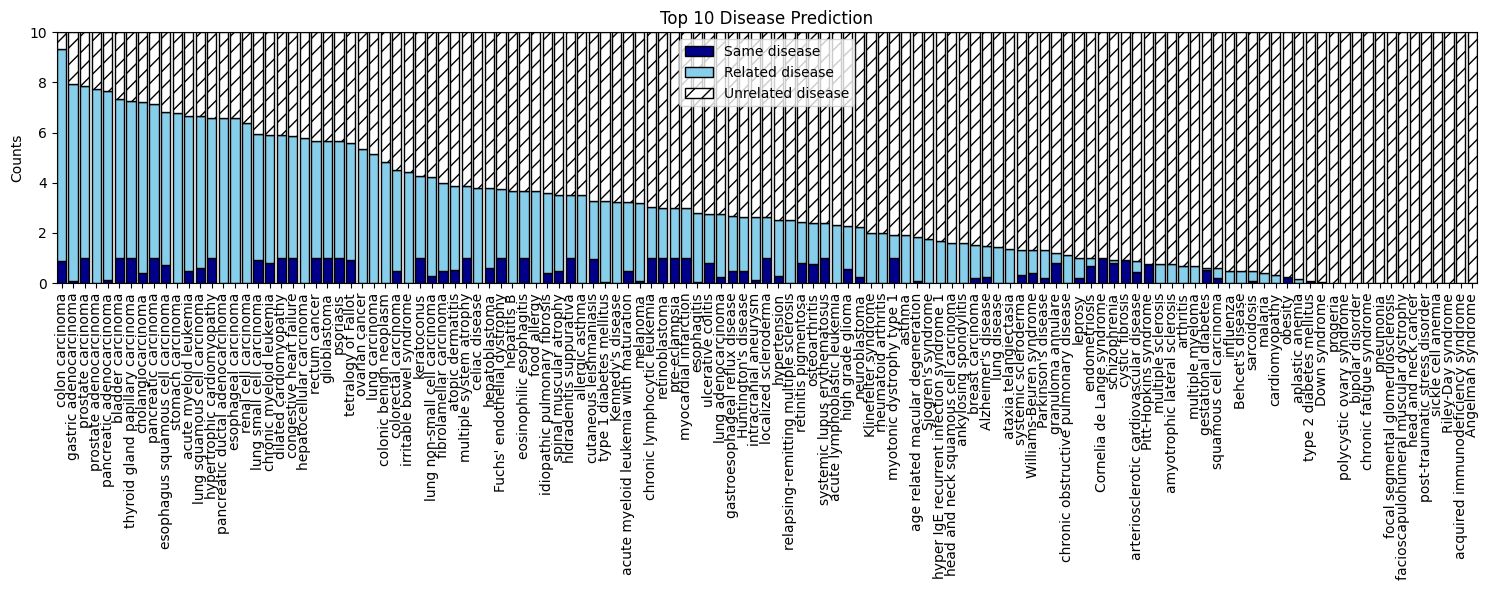

In [ ]:
k = 10
df_hits = hit_at_k_from_proba(y_test, y_proba, d_related, k=k)

doid_2_dis = dict(zip(adata_train.obs["doid_id"], adata_train.obs["doid_disease"]))
df_hits["disease"] = df_hits["doid"].map(doid_2_dis)

_df_grouped = df_hits.groupby("disease")[["hit@k","n_related","n_unrelated"]].mean().sort_values(["n_unrelated"])

dis_order = _df_grouped.index.to_list()
_same_counts = _df_grouped["hit@k"].to_list()
_related_counts = _df_grouped["n_related"].to_list()
_unrelated_counts = _df_grouped["n_unrelated"].to_list()


x = np.arange(len(_df_grouped))

fig, ax = plt.subplots(figsize=(15, 6))

# Stacked vertical bars
bars_same = ax.bar(x, _same_counts, color="darkblue", label="Same disease", edgecolor="black")
bars_related = ax.bar(x, _related_counts, bottom=_same_counts,
                      color="skyblue", label="Related disease", edgecolor="black")
bars_unrelated = ax.bar(
    x, _unrelated_counts,
    bottom=np.array(_same_counts) + np.array(_related_counts),
    color="white", edgecolor="black", hatch="//", label="Unrelated disease"
)

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(dis_order, rotation=90)
ax.set_ylabel("Counts")
ax.set_title(f"Top {k} Disease Prediction")
ax.legend()

    
plt.margins(x=0.0, y=0.0)
plt.ylim(-0.0, k)  # adjust if your totals differ
plt.tight_layout()
plt.show()


In [ ]:
_df_grouped_std = df_hits.groupby("disease")[["hit@k","n_related","n_unrelated"]].std().sort_values(["n_unrelated"])

In [ ]:
_df_grouped_std.rename(columns={"hit@k": "hit@k_std", "n_related": "n_related_std", "n_unrelated": "n_unrelated_std"}, inplace=True)
_df_grouped_std

# joing by disease id
_df_grouped = pd.DataFrame(_df_grouped).join(_df_grouped_std, how="inner")

In [ ]:
_df_grouped

,hit@k,n_related,n_unrelated,hit@k_std,n_related_std,n_unrelated_std
disease,,,,,,
colon carcinoma,0.900000,8.450000,0.650000,0.307794,0.604805,0.812728
gastric adenocarcinoma,0.074667,7.866667,2.058667,0.263204,1.313579,1.282033
prostate carcinoma,1.000000,6.857143,2.142857,0.000000,0.534522,0.534522
prostate adenocarcinoma,0.000000,7.722222,2.277778,0.000000,0.669113,0.669113
pancreatic adenocarcinoma,0.129213,7.544944,2.325843,0.336382,1.041892,1.017089
...,...,...,...,...,...,...
post-traumatic stress disorder,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000
sickle cell anemia,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000
Riley-Day syndrome,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000


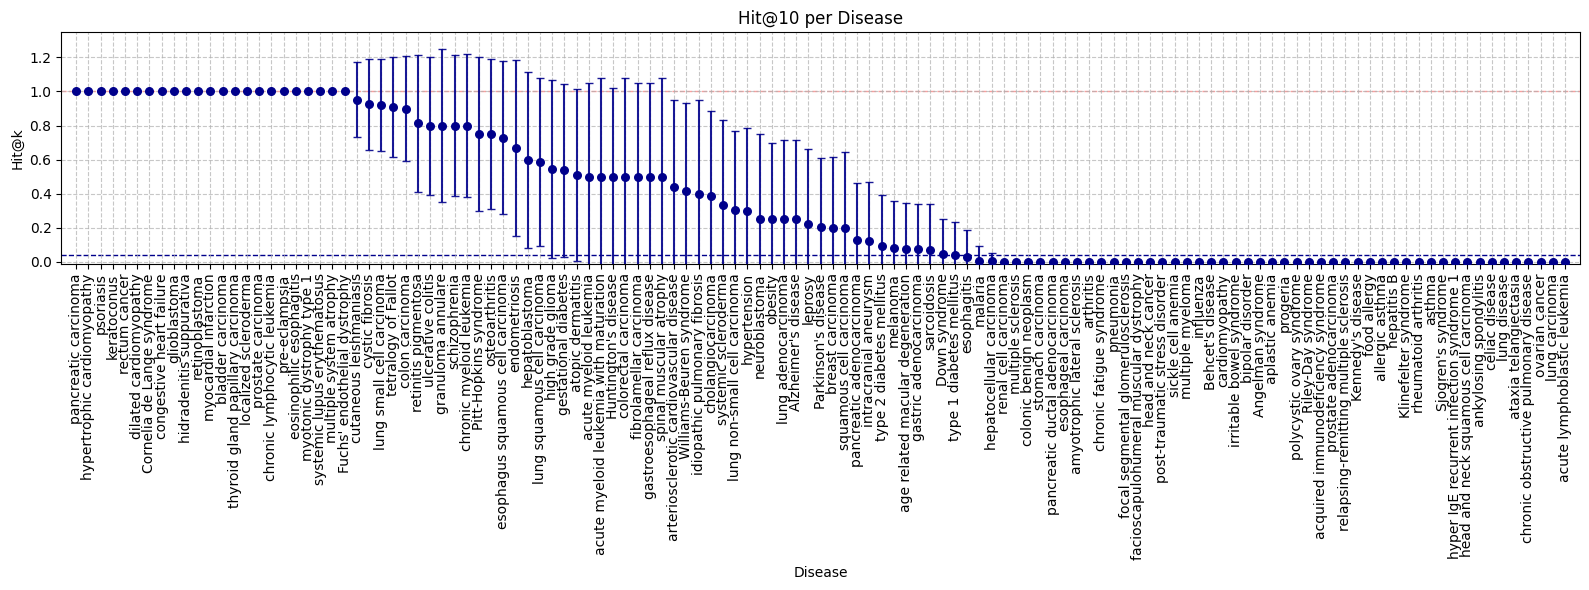

In [ ]:
_df_grouped.std()

hit@k              0.406382
n_related          2.258404
n_unrelated        2.384880
hit@k_std          0.219851
n_related_std      0.529260
n_unrelated_std    0.539011
dtype: float64

In [ ]:
np.array(le.classes_)[np.argsort(-y_proba, axis=1)[:, :k]]

array([['DOID:768', 'DOID:0080199', 'DOID:10584', ..., 'DOID:10941',
        'DOID:13922', 'DOID:4007'],
       ['DOID:768', 'DOID:3908', 'DOID:10584', ..., 'DOID:4007',
        'DOID:3310', 'DOID:5015'],
       ['DOID:768', 'DOID:3908', 'DOID:12449', ..., 'DOID:3310',
        'DOID:10941', 'DOID:4007'],
       ...,
       ['DOID:2377', 'DOID:8577', 'DOID:3310', ..., 'DOID:8398',
        'DOID:2394', 'DOID:3312'],
       ['DOID:2377', 'DOID:8577', 'DOID:3459', ..., 'DOID:10871',
        'DOID:3083', 'DOID:3310'],
       ['DOID:2377', 'DOID:8577', 'DOID:3459', ..., 'DOID:10871',
        'DOID:3083', 'DOID:3907']], dtype=object)

In [ ]:
le.inverse_transform(le.transform(yv_str))

array(['DOID:768', 'DOID:768', 'DOID:768', ..., 'DOID:635', 'DOID:635',
       'DOID:635'], dtype=object)

In [ ]:
"""0.2 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports


# variables

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

Loaded universe of disease pairs: 70442515
IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


In [ ]:
auroc_per_class = {}
auprc_per_class = {}
for c, name in enumerate(le.classes_):
    y_true_c = (y_test == c).astype(int)
    if y_true_c.sum() == 0:        # this class might not appear in the filtered test set
        continue
    auroc_per_class[name] = roc_auc_score(y_true_c, y_proba[:, c])
    auprc_per_class[name] = average_precision_score(y_true_c, y_proba[:, c])


In [ ]:
auprc_per_class

{'DOID:0050156': 0.007089322583134004,
 'DOID:0050700': 0.005391450130836612,
 'DOID:0060161': 0.0035179521453433554,
 'DOID:0060488': 0.36174830450605244,
 'DOID:0080199': 0.019897330642018644,
 'DOID:0081087': 0.043863822958650545,
 'DOID:10126': 0.9999999999999998,
 'DOID:1024': 0.009121644543111287,
 'DOID:10286': 0.48874196266401415,
 'DOID:1040': 0.9927534641570493,
 'DOID:10584': 0.22380575570060865,
 'DOID:10591': 0.12878787878787878,
 'DOID:10608': 0.009256911808471754,
 'DOID:10652': 0.006938177794924016,
 'DOID:10763': 0.016104824317736827,
 'DOID:10871': 0.07135463269611776,
 'DOID:10923': 0.004294002853484278,
 'DOID:10941': 0.011312997181066852,
 'DOID:1107': 0.05435462619987841,
 'DOID:11335': 0.016702594913876056,
 'DOID:11555': 1.0,
 'DOID:11589': 0.002529075930695999,
 'DOID:11612': 0.007069311307510752,
 'DOID:11714': 0.1733361747163519,
 'DOID:11722': 0.31252931786146065,
 'DOID:11725': 1.0,
 'DOID:11727': 0.0026716373848290585,
 'DOID:11934': 0.002884284157634713,


In [ ]:
np.mean(list(auroc_per_class.values()))

0.7279487093683157

In [ ]:
le.classes_

array(['DOID:0050156', 'DOID:0050700', 'DOID:0060161', 'DOID:0060488',
       'DOID:0080199', 'DOID:0081087', 'DOID:10126', 'DOID:1024',
       'DOID:10286', 'DOID:1040', 'DOID:10584', 'DOID:10591',
       'DOID:10608', 'DOID:10652', 'DOID:10763', 'DOID:10871',
       'DOID:10923', 'DOID:10941', 'DOID:1107', 'DOID:11335',
       'DOID:11555', 'DOID:11589', 'DOID:11612', 'DOID:11714',
       'DOID:11722', 'DOID:11725', 'DOID:11727', 'DOID:11934',
       'DOID:11963', 'DOID:11984', 'DOID:12365', 'DOID:12377',
       'DOID:12449', 'DOID:12704', 'DOID:12858', 'DOID:12894',
       'DOID:12930', 'DOID:1312', 'DOID:13241', 'DOID:13922',
       'DOID:14250', 'DOID:14330', 'DOID:1485', 'DOID:1520', 'DOID:1749',
       'DOID:1909', 'DOID:1921', 'DOID:1928', 'DOID:1932', 'DOID:1993',
       'DOID:2043', 'DOID:2055', 'DOID:2280', 'DOID:2348', 'DOID:235',
       'DOID:2377', 'DOID:2378', 'DOID:2394', 'DOID:2526', 'DOID:2841',
       'DOID:289', 'DOID:3044', 'DOID:3068', 'DOID:3070', 'DOID:3083',
  

In [ ]:
def hit_at_k_from_proba(y_true_int, proba, k=5):
    topk = np.argsort(-proba, axis=1)[:, :k]  # top-k indices (unordered)
    # check if true label is in top-k set per row
    hits = [int(t in row) for t, row in zip(y_true_int, topk)]
    return np.mean(hits)

In [ ]:
def hit_at_k_from_proba(y_true_int, proba, k=5):
    topk = np.argpartition(-proba, kth=k-1, axis=1)[:, :k]  # top-k indices (unordered)
    # check if true label is in top-k set per row
    hits = [int(t in row) for t, row in zip(y_true_int, topk)]
    return np.mean(hits)

In [ ]:
# kNN with OneVsRestClassifier for probability-based metrics (AUROC, AUPRC, Hit@k)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier

# 1) Encode labels using TRAIN classes only
le = LabelEncoder().fit(adata_train.obs["doid_id"].values)
y_train = le.transform(adata_train.obs["doid_id"].values)

# train
clf = OneVsRestClassifier(KNeighborsClassifier(n_neighbors=5))
clf.fit(embeddings_train, y_train)

# 2) testation: restrict to doid_ids seen in TRAIN
test_labels = adata_test.obs["doid_id"].values
seen_mask = np.isin(test_labels, le.classes_)                 # only seen doid_ids
Xv = embeddings_test[seen_mask]
yv_str = test_labels[seen_mask]
y_test = le.transform(yv_str)                                  # integer labels (seen only)
print(f"Evaluating on {len(y_test)} test cells from {len(le.classes_)} seen classes")
print(f"Nº of embeddings {Xv.shape} from original {embeddings_test.shape} ")


# 3) Probabilities (no hard predict)
y_proba = clf.predict_proba(Xv)                                 # shape (n_samples, n_train_classes)

# 4) Probability-based metrics
#    (a) Macro AUROC (OvR) and Macro AUPRC over seen classes
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
auroc_macro = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
auprc_macro = average_precision_score(y_test_bin, y_proba, average="macro")

print(f"Macro AUROC (seen classes): {auroc_macro:.3f}")
print(f"Macro AUPRC (seen classes): {auprc_macro:.3f}")

#    (b) Per-class AUROC/AUPRC (optional, useful for doid_id-level reporting)
auroc_per_class = {}
auprc_per_class = {}
for c, name in enumerate(le.classes_):
    y_true_c = (y_test == c).astype(int)
    if y_true_c.sum() == 0:        # this class might not appear in the filtered test set
        continue
    auroc_per_class[name] = roc_auc_score(y_true_c, y_proba[:, c])
    auprc_per_class[name] = average_precision_score(y_true_c, y_proba[:, c])

# 5) Optional: Top-k from probabilities (still no hard predict)
def hit_at_k_from_proba(y_true_int, proba, k=5):
    topk = np.argsort(-proba,axis=1)[:, :k]  # top-k indices (unordered)
    # check if true label is in top-k set per row
    hits = [int(t in row) for t, row in zip(y_true_int, topk)]
    return np.mean(hits)

for k in (1, 5, 10):
    print(f"Hit@{k} (seen classes): {hit_at_k_from_proba(y_test, y_proba, k=k):.3f}")

# Notes:
# - No classification_report or confusion matrix here, since you asked to avoid predict().
# - If you still need a confusion matrix later, use np.argmax(y_proba, axis=1) to get hard labels.


Evaluating on 5248 test cells from 124 seen classes
Nº of embeddings (5248, 512) from original (5248, 512) 
Macro AUROC (seen classes): 0.576
Macro AUPRC (seen classes): 0.081
Hit@1 (seen classes): 0.242
Hit@5 (seen classes): 0.340
Hit@10 (seen classes): 0.352


In [ ]:
def hit_at_k_from_proba(y_true_int, proba, k=5):
    topk = np.argsort(-proba, kth=k-1, axis=1)[:, :k]  # top-k indices (unordered)
    # check if true label is in top-k set per row
    hits = [int(t in row) for t, row in zip(y_true_int, topk)]
    return np.mean(hits)

In [ ]:
np.argsort(-y_proba[0])[:5]

array([  0,  11, 113, 114, 115])

In [ ]:
np.argpartition(-y_proba, kth=5-1, axis=1)[:, :5]

array([[ 11,   0,  83,  82,  81],
       [  0, 102,  84,  83,  81],
       [ 11,   0,  83,  82,  81],
       ...,
       [ 58,  56,  70,   0,  44],
       [ 84,   0,  56,  85,  83],
       [ 84,   0,  56,  85,  83]])

In [ ]:
# MLP with OneVsRestClassifier for probability-based metrics (AUROC, AUPRC, Hit@k)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier

# 1) Encode labels using TRAIN classes only
le = LabelEncoder().fit(adata_train.obs["doid_id"].values)
y_train = le.transform(adata_train.obs["doid_id"].values)

# train
clf = OneVsRestClassifier(MLPClassifier(hidden_layer_sizes=(256,)), n_jobs=-1)
clf.fit(embeddings_train, y_train)

# 2) testation: restrict to doid_ids seen in TRAIN
test_labels = adata_test.obs["doid_id"].values
seen_mask = np.isin(test_labels, le.classes_)                 # only seen doid_ids
Xv = embeddings_test[seen_mask]
yv_str = test_labels[seen_mask]
y_test = le.transform(yv_str)                                  # integer labels (seen only)
print(f"Evaluating on {len(y_test)} test cells from {len(le.classes_)} seen classes")
print(f"Nº of embeddings {Xv.shape} from original {embeddings_test.shape} ")


# 3) Probabilities (no hard predict)
y_proba = clf.predict_proba(Xv)                                 # shape (n_samples, n_train_classes)

# 4) Probability-based metrics
#    (a) Macro AUROC (OvR) and Macro AUPRC over seen classes
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
auroc_macro = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
auprc_macro = average_precision_score(y_test_bin, y_proba, average="macro")

print(f"Macro AUROC (seen classes): {auroc_macro:.3f}")
print(f"Macro AUPRC (seen classes): {auprc_macro:.3f}")

#    (b) Per-class AUROC/AUPRC (optional, useful for doid_id-level reporting)
auroc_per_class = {}
auprc_per_class = {}
for c, name in enumerate(le.classes_):
    y_true_c = (y_test == c).astype(int)
    if y_true_c.sum() == 0:        # this class might not appear in the filtered test set
        continue
    auroc_per_class[name] = roc_auc_score(y_true_c, y_proba[:, c])
    auprc_per_class[name] = average_precision_score(y_true_c, y_proba[:, c])

# 5) Optional: Top-k from probabilities (still no hard predict)
def hit_at_k_from_proba(y_true_int, proba, k=5):
    topk = np.argpartition(-proba, kth=k-1, axis=1)[:, :k]  # top-k indices (unordered)
    # check if true label is in top-k set per row
    hits = [int(t in row) for t, row in zip(y_true_int, topk)]
    return np.mean(hits)

for k in (1, 5, 10):
    print(f"Hit@{k} (seen classes): {hit_at_k_from_proba(y_test, y_proba, k=k):.3f}")
    

/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/home/ddalton/Data/old_home/miniconda3/envs/scgpt

KeyboardInterrupt: 